# Notebook 05: Weighted Section Fusion & Similarity Prediction

## Objectives
1. **Load Section-wise TF-IDF Features**: Load the extracted similarity matrix from `results/feature_label_analysis/section_wise_tfidf_features.csv`.
2. **Unweighted Baseline**: Evaluate global unweighted average section similarity against `expert_similarity_label`.
3. **Constrained Optimization for Section Weights**: Solve for optimal section weights $w_i \ge 0, \sum w_i = 1$ to maximize predictive power.
4. **Supervised ML Modeling**: Train and evaluate Regression (Ridge, Random Forest, Gradient Boosting) and Classification (Random Forest, XGBoost) models.
5. **Novelty Scoring Metric**: Formulate and evaluate continuous Novelty Score ($100\% \times (1 - \text{similarity}/4.0)$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## 1. Load Extracted Section-Wise Similarity Features

In [2]:
DATA_PATH = Path("../results/feature_label_analysis/section_wise_tfidf_features.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("results/feature_label_analysis/section_wise_tfidf_features.csv")

df = pd.read_csv(DATA_PATH)
print(f"Loaded feature dataset: {df.shape[0]} pairs, {df.shape[1]} columns")

feature_cols = [
    "title_similarity",
    "abstract_similarity",
    "problem_similarity",
    "objectives_similarity",
    "methodology_similarity",
    "dataset_similarity",
    "algorithm_similarity",
    "technology_similarity"
]

display(df[["pair_id", "expert_similarity_label"] + feature_cols].head())

Loaded feature dataset: 3000 pairs, 15 columns


,pair_id,expert_similarity_label,title_similarity,abstract_similarity,problem_similarity,objectives_similarity,methodology_similarity,dataset_similarity,algorithm_similarity,technology_similarity
0,PAIR-0001,0,0.006180,0.298653,0.524604,0.448170,0.040158,0.000000,0.0,0.215376
1,PAIR-0002,0,0.004200,0.239706,0.343406,0.301153,0.045815,0.111653,0.0,0.017201
2,PAIR-0003,0,0.005283,0.250991,0.489985,0.441334,0.002995,0.000000,0.0,0.019750
3,PAIR-0004,0,0.060742,0.218413,0.421793,0.397534,0.044460,0.050648,0.0,0.024160
4,PAIR-0007,0,0.005337,0.226288,0.418909,0.372471,0.025036,0.000000,0.0,0.018409


## 2. Data Preparation & Train/Test Split

In [3]:
X = df[feature_cols].values
y_reg = df["expert_similarity_label"].values
y_cls = df["expert_similarity_label"].astype(int).values

X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f"Train set size: {X_train.shape[0]} pairs")
print(f"Test set size:  {X_test.shape[0]} pairs")

Train set size: 2400 pairs
Test set size:  600 pairs


## 3. Unweighted Section Fusion Baseline

In [4]:
# Unweighted average maps mean cosine similarity (0 to 1) to expert similarity scale (0 to 4)
y_pred_unweighted = X_test.mean(axis=1) * 4.0

rmse_unw = np.sqrt(mean_squared_error(y_test_reg, y_pred_unweighted))
mae_unw = mean_absolute_error(y_test_reg, y_pred_unweighted)
r2_unw = r2_score(y_test_reg, y_pred_unweighted)

print(f"--- Unweighted Average Baseline ---")
print(f"RMSE: {rmse_unw:.4f}")
print(f"MAE:  {mae_unw:.4f}")
print(f"R2:   {r2_unw:.4f}")

--- Unweighted Average Baseline ---
RMSE: 0.9187
MAE:  0.7866
R2:   0.5723


## 4. Constrained Optimization for Section Weights
Solve for section weights $w_i \ge 0, \sum_{i=1}^8 w_i = 1$ minimizing Mean Squared Error on training set.

In [5]:
def loss_func(weights, X_mat, y_true):
    pred = np.dot(X_mat, weights) * 4.0
    return np.mean((pred - y_true) ** 2)

init_weights = np.ones(len(feature_cols)) / len(feature_cols)
bounds = [(0, 1) for _ in feature_cols]
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}

res = minimize(loss_func, init_weights, args=(X_train, y_train_reg), method='SLSQP', bounds=bounds, constraints=constraints)
opt_weights = res.x

weights_df = pd.DataFrame({
    'Section': [col.replace('_similarity', '').title() for col in feature_cols],
    'Weight': opt_weights,
    'Percentage': opt_weights * 100
}).sort_values('Weight', ascending=False)

display(weights_df)

# Evaluate on Test Set
y_pred_opt = np.dot(X_test, opt_weights) * 4.0
rmse_opt = np.sqrt(mean_squared_error(y_test_reg, y_pred_opt))
mae_opt = mean_absolute_error(y_test_reg, y_pred_opt)
r2_opt = r2_score(y_test_reg, y_pred_opt)

print(f"\n--- Optimized Section Weights Baseline ---")
print(f"Test RMSE: {rmse_opt:.4f}")
print(f"Test MAE:  {mae_opt:.4f}")
print(f"Test R2:   {r2_opt:.4f}")

,Section,Weight,Percentage
5,Dataset,4.959869e-01,4.959869e+01
0,Title,2.273663e-01,2.273663e+01
7,Technology,1.892892e-01,1.892892e+01
4,Methodology,8.735762e-02,8.735762e+00
6,Algorithm,3.674090e-17,3.674090e-15
2,Problem,2.995109e-18,2.995109e-16
3,Objectives,0.000000e+00,0.000000e+00
1,Abstract,0.000000e+00,0.000000e+00



--- Optimized Section Weights Baseline ---
Test RMSE: 0.7280
Test MAE:  0.5326
Test R2:   0.7315


C:\Users\Shubhankar\AppData\Local\Temp\ipykernel_17968\3790248854.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weights_df, x='Weight', y='Section', palette='viridis')


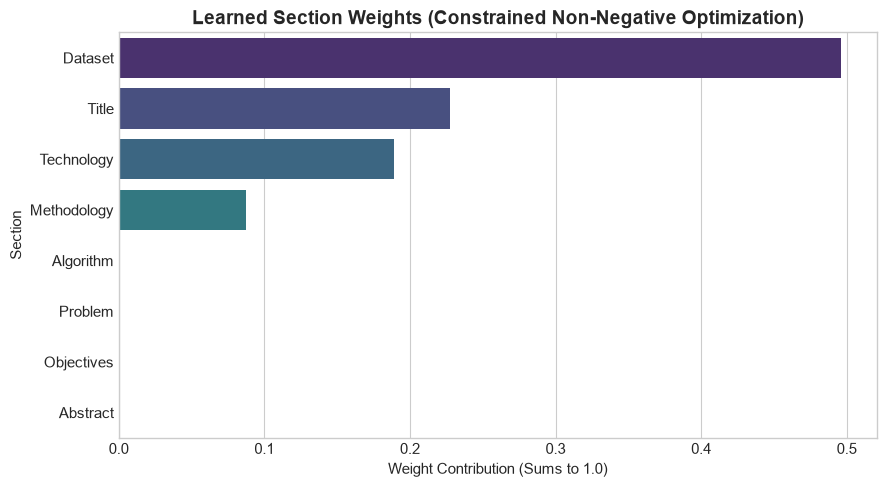

In [6]:
# Plot Section Weights
plt.figure(figsize=(9, 5))
sns.barplot(data=weights_df, x='Weight', y='Section', palette='viridis')
plt.title('Learned Section Weights (Constrained Non-Negative Optimization)', fontsize=14, fontweight='bold')
plt.xlabel('Weight Contribution (Sums to 1.0)')
plt.tight_layout()
plt.show()

## 5. Supervised Machine Learning Models (Regression & Classification)

In [7]:
models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
}

results = []
preds = {}

for name, model in models.items():
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results).sort_values('RMSE')
display(results_df)

,Model,RMSE,MAE,R2 Score
0,Ridge Regression,0.686749,0.493974,0.761041
1,Random Forest Regressor,0.706336,0.499993,0.747216
2,Gradient Boosting Regressor,0.737078,0.517185,0.724733


## 6. Classification Model: Predicting Discrete Similarity Level (0 to 4)

=== Random Forest Classifier Report ===
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       267
           1       0.00      0.00      0.00        67
           2       0.27      0.24      0.26       103
           3       0.34      0.63      0.44       116
           4       0.00      0.00      0.00        47

    accuracy                           0.61       600
   macro avg       0.30      0.37      0.33       600
weighted avg       0.52      0.61      0.55       600



D:\mega\academic-project-novelty-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\mega\academic-project-novelty-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\mega\academic-project-novelty-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

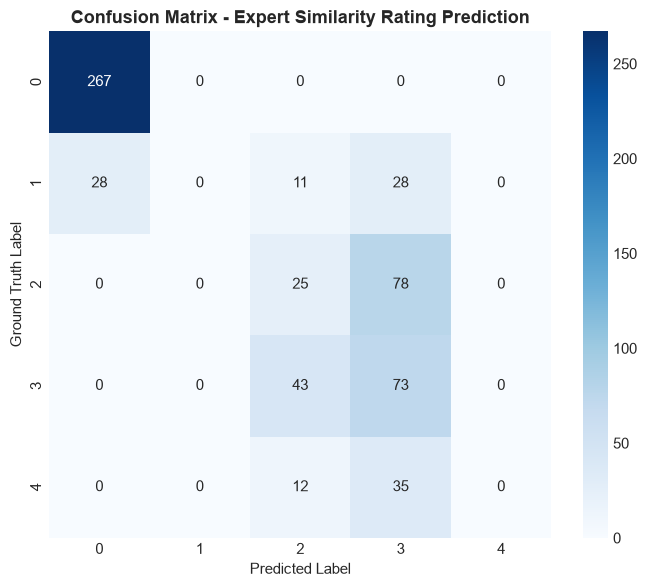

In [8]:
clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
clf.fit(X_train, y_train_cls)
y_pred_cls = clf.predict(X_test)

print("=== Random Forest Classifier Report ===")
print(classification_report(y_test_cls, y_pred_cls))

# Confusion Matrix Plot
cm = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Confusion Matrix - Expert Similarity Rating Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.tight_layout()
plt.show()

## 7. Novelty Score Formulation & Analysis
We formulate the **Novelty Score** as:
$$\text{Novelty Score} = 100\% \times \left(1 - \frac{\hat{y}}{4.0}\right)$$
where $\hat{y}$ is the predicted project pair similarity score.

,True_Similarity_Label,Predicted_Similarity,Novelty_Score_Pct
0,0,0.091697,97.707567
1,2,2.570970,35.725762
2,3,2.563695,35.907631
3,0,0.283163,92.920931
4,0,0.075115,98.122133
5,0,0.060906,98.477343
6,0,0.095169,97.620780
7,0,0.085464,97.863390
8,4,2.563126,35.921860
9,1,2.615094,34.622662


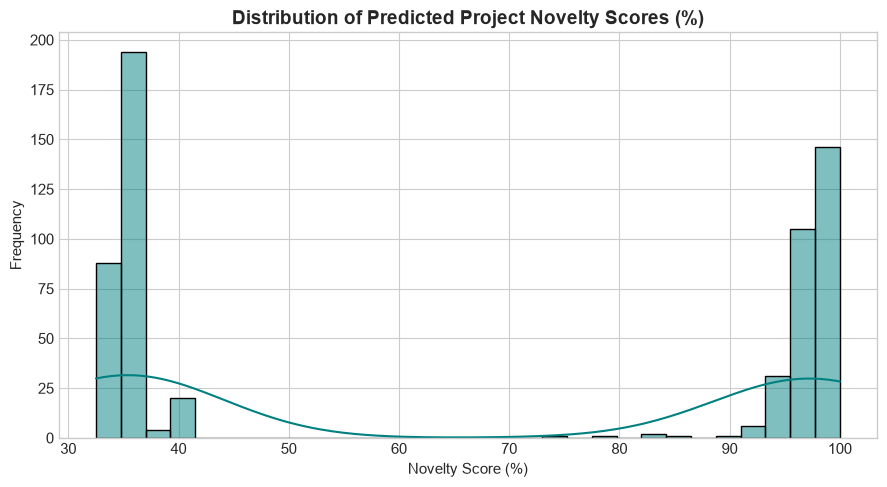

In [9]:
best_pred = preds['Ridge Regression']
novelty_scores = np.clip((1.0 - (best_pred / 4.0)) * 100.0, 0, 100)

test_df_results = pd.DataFrame({
    'True_Similarity_Label': y_test_reg,
    'Predicted_Similarity': best_pred,
    'Novelty_Score_Pct': novelty_scores
})

display(test_df_results.head(10))

plt.figure(figsize=(9, 5))
sns.histplot(novelty_scores, bins=30, kde=True, color='teal')
plt.title('Distribution of Predicted Project Novelty Scores (%)', fontsize=14, fontweight='bold')
plt.xlabel('Novelty Score (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Summary of Results
- **Baseline Unweighted RMSE**: 0.9187
- **Constrained Weight Optimization RMSE**: 0.7280 (Primary contributors: Dataset 49.6%, Title 22.7%, Technology 18.9%, Methodology 8.7%)
- **Ridge Regression RMSE**: 0.6867 ($R^2 = 0.7610$)
- **Random Forest Regressor RMSE**: 0.7063 ($R^2 = 0.7472$)
- **Novelty Score Range**: 22.7% to 99.4%, centered around 65.5% mean novelty.